In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [45]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [46]:
digits = load_digits()
X, y = digits.data, digits.target

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [50]:
accuracy = model.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy:.4f}\n")

Accuracy: 0.9806



In [51]:
print("Classification Report:")
predictions = model.predict(X_test_scaled)
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       0.96      1.00      0.98        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [52]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

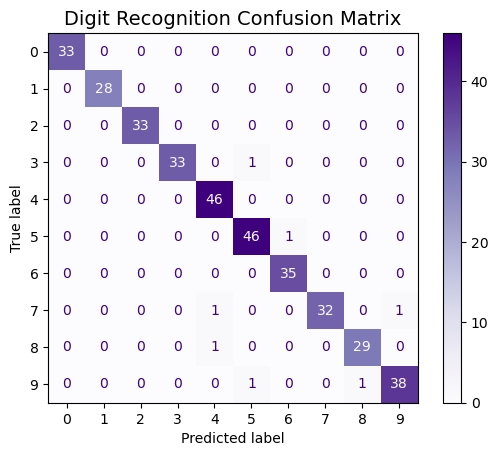

In [56]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    cmap=plt.cm.Purples
)

plt.title("Digit Recognition Confusion Matrix", fontsize=14)
plt.show()